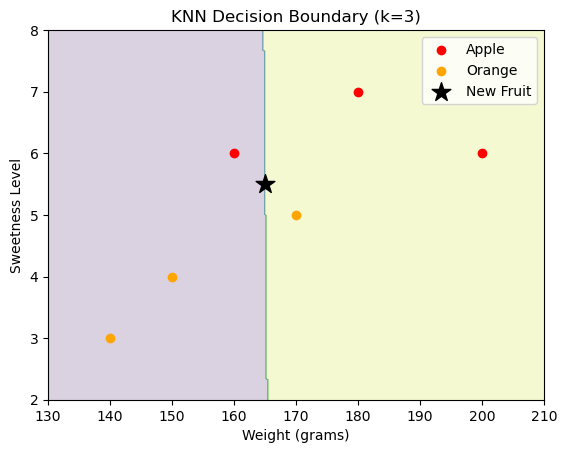

In [2]:
def simple_knn_predict(X, y, new_point, k):
    distances = []

    for i in range(len(X)):
        distance = euclidean_distance(X[i], new_point)
        distances.append((distance, y[i]))

    distances.sort(key=lambda x: x[0])

    neighbors = distances[:k]

    labels = [label for distance, label in neighbors]

    return "Apple" if labels.count("Apple") > labels.count("Orange") else "Orange"


# Create grid
x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = np.array([
    1 if simple_knn_predict(X, y, point, 3) == "Apple" else 0
    for point in grid
])

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2)

apple = X[y == "Apple"]
orange = X[y == "Orange"]

plt.scatter(
    apple[:, 0], apple[:, 1],
    color="red",
    label="Apple"
)

plt.scatter(
    orange[:, 0], orange[:, 1],
    color="orange",
    label="Orange"
)

plt.scatter(
    new_fruit[0], new_fruit[1],
    color="black",
    marker="*",
    s=200,
    label="New Fruit"
)

plt.xlabel("Weight (grams)")
plt.ylabel("Sweetness Level")
plt.title("KNN Decision Boundary (k=3)")
plt.legend()
plt.show()

Euclidean distances:
[15.07481343 35.00357125 15.07481343  5.02493781  5.02493781 25.12468905]

Manhattan distances:
[16.5 35.5 16.5  5.5  5.5 27.5]

Minkowski distances (p=3):
[15.00499833 35.00003401 15.00499833  5.00166611  5.00166611 25.00833056]

Predicted class: Orange


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

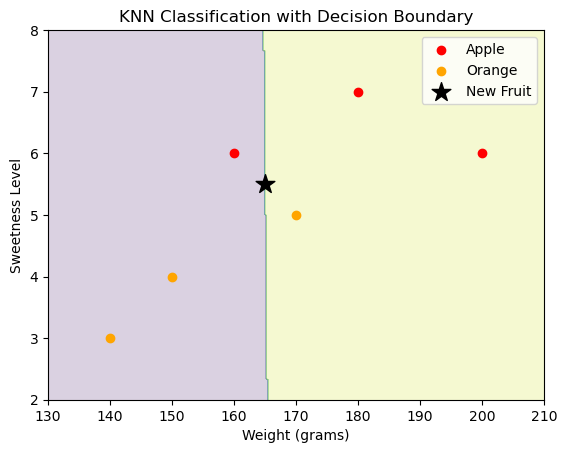

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import pairwise_distances


# Dataset
X = np.array([
    [180, 7],
    [200, 6],
    [150, 4],
    [170, 5],
    [160, 6],
    [140, 3]
])

y = np.array([
    "Apple",
    "Apple",
    "Orange",
    'Banana',
    "Orange",
    "Apple",
    "Orange"
])

# New fruit
new_fruit = np.array([[165, 5.5]])


# --------------------------------------------------
# Euclidean distances
# --------------------------------------------------

euclidean = pairwise_distances(
    new_fruit,
    X,
    metric="euclidean"
)[0]

print("Euclidean distances:")
print(euclidean)


# --------------------------------------------------
# Manhattan distances
# --------------------------------------------------

manhattan = pairwise_distances(
    new_fruit,
    X,
    metric="manhattan"
)[0]

print("\nManhattan distances:")
print(manhattan)


# --------------------------------------------------
# Minkowski distances
# p = 3
# --------------------------------------------------

minkowski = pairwise_distances(
    new_fruit,
    X,
    metric="minkowski",
    p=3
)[0]

print("\nMinkowski distances (p=3):")
print(minkowski)


# --------------------------------------------------
# KNN classifier
# --------------------------------------------------

knn = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

knn.fit(X, y)

prediction = knn.predict(new_fruit)

print("\nPredicted class:", prediction[0])


# --------------------------------------------------
# Decision boundary
# --------------------------------------------------

x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = knn.predict(grid)

# Convert labels to numbers for contour plot
Z = np.where(Z == "Apple", 1, 0)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2)

# Apple points
apple = X[y == "Apple"]

plt.scatter(
    apple[:, 0],
    apple[:, 1],
    color="red",
    label="Apple"
)

# Orange points
orange = X[y == "Orange"]

plt.scatter(
    orange[:, 0],
    orange[:, 1],
    color="orange",
    label="Orange"
)

# New fruit
plt.scatter(
    new_fruit[:, 0],
    new_fruit[:, 1],
    color="black",
    marker="*",
    s=200,
    label="New Fruit"
)

plt.xlabel("Weight (grams)")
plt.ylabel("Sweetness Level")
plt.title("KNN Classification with Decision Boundary")
plt.legend()
plt.show()